<a href="https://colab.research.google.com/github/ElBaron-27/UACJ_Ruben/blob/main/Taylor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Datos de la tabla ----
salarios = np.array([6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30])
prob_real = np.array([0.0000,0.0600,0.0200,0.0000,0.0400,0.0399,0.0397,0.0191,0.0175,0.0533,
                       0.0220,0.0274,0.0592,0.2489,0.4400,0.7311,0.8208,0.9126,0.9820,0.9933,
                       0.9775,0.9391,0.9997,0.9599,0.9800])

# ---- Punto de expansión (Ejercicio 1) ----
x0 = 20

# ---- Coeficientes del polinomio de Taylor orden 3 (Ejercicio 2) ----
# Derivados de f'=f(1-f) evaluados en x0, donde f(x0)=0.5
f_x0  = 0.5
f1_x0 = 0.25     # f'(x0)
f2_x0 = 0.0      # f''(x0)
f3_x0 = -0.125   # f'''(x0)

# Revisar derivadas en PDF


In [4]:
#Me genera esta función que voy a utilizar para evaluar el polinomio en cada salario

def P3(x):
    return (f_x0
            + f1_x0 * (x - x0)
            + (f2_x0 / 2) * (x - x0)**2
            + (f3_x0 / 6) * (x - x0)**3)

# ---- Ejercicio 3: evaluar el polinomio en cada salario ----
prob_aprox = P3(salarios)
print(prob_aprox)

[ 54.16666667  43.02083333  33.5         25.47916667  18.83333333
  13.4375       9.16666667   5.89583333   3.5          1.85416667
   0.83333333   0.3125       0.16666667   0.27083333   0.5
   0.72916667   0.83333333   0.6875       0.16666667  -0.85416667
  -2.5         -4.89583333  -8.16666667 -12.4375     -17.83333333]


In [5]:
# ---- Ejercicio 4: error absoluto ----
error_abs = np.abs(prob_aprox - prob_real)

print(f"{'Salario':<10}{'Real':<10}{'Aproximado':<12}{'Error':<10}")
for s, r, a, e in zip(salarios, prob_real, prob_aprox, error_abs):
    print(f"{s:<10}{r:<10.4f}{a:<12.4f}{e:<10.4f}")

print(f"\nError promedio: {error_abs.mean():.4f}")
print(f"Error máximo:   {error_abs.max():.4f} (en salario = {salarios[np.argmax(error_abs)]})")


Salario   Real      Aproximado  Error     
6         0.0000    54.1667     54.1667   
7         0.0600    43.0208     42.9608   
8         0.0200    33.5000     33.4800   
9         0.0000    25.4792     25.4792   
10        0.0400    18.8333     18.7933   
11        0.0399    13.4375     13.3976   
12        0.0397    9.1667      9.1270    
13        0.0191    5.8958      5.8767    
14        0.0175    3.5000      3.4825    
15        0.0533    1.8542      1.8009    
16        0.0220    0.8333      0.8113    
17        0.0274    0.3125      0.2851    
18        0.0592    0.1667      0.1075    
19        0.2489    0.2708      0.0219    
20        0.4400    0.5000      0.0600    
21        0.7311    0.7292      0.0019    
22        0.8208    0.8333      0.0125    
23        0.9126    0.6875      0.2251    
24        0.9820    0.1667      0.8153    
25        0.9933    -0.8542     1.8475    
26        0.9775    -2.5000     3.4775    
27        0.9391    -4.8958     5.8349    
28        0


Gráfica guardada como comparacion_taylor.png
Gráfica de acercamiento guardada como comparacion_taylor_zoom.png


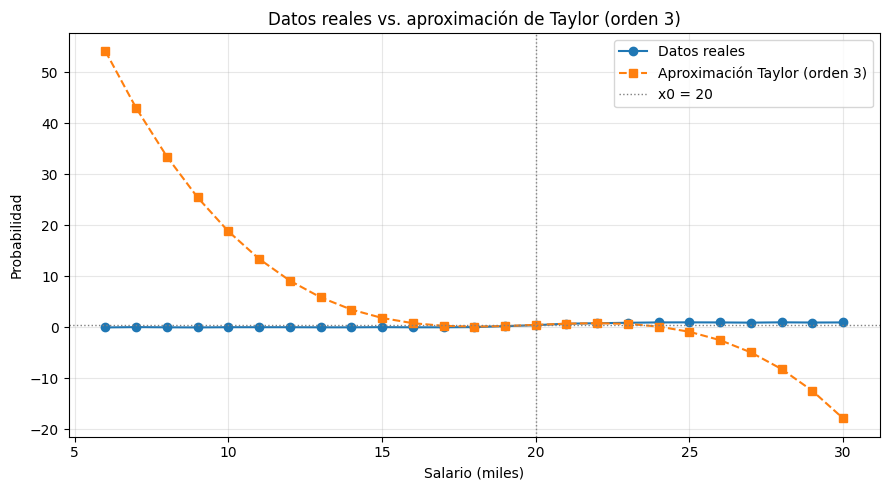

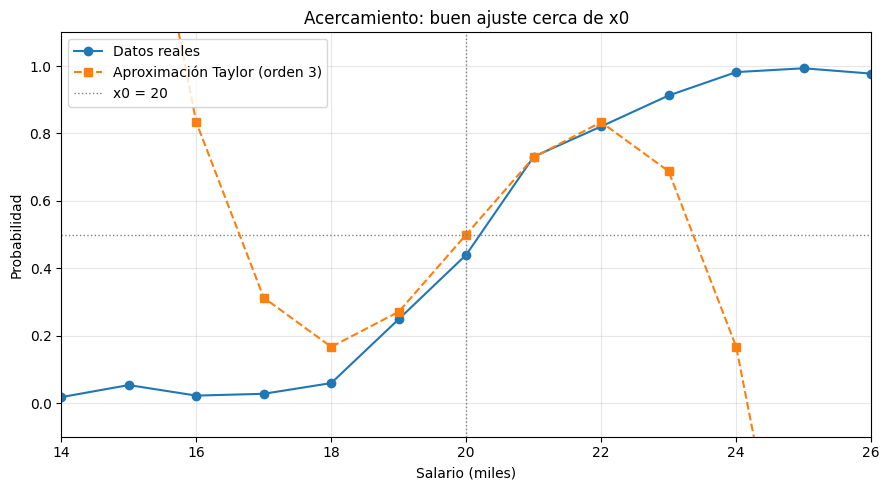

In [7]:
# ---- Ejercicio 5: gráfica comparativa ----
plt.figure(figsize=(9,5))
plt.plot(salarios, prob_real, 'o-', label='Datos reales')
plt.plot(salarios, prob_aprox, 's--', label='Aproximación Taylor (orden 3)')
plt.axhline(0.5, color='gray', linestyle=':', linewidth=1)
plt.axvline(x0, color='gray', linestyle=':', linewidth=1, label=f'x0 = {x0}')
plt.xlabel('Salario (miles)')
plt.ylabel('Probabilidad')
plt.title('Datos reales vs. aproximación de Taylor (orden 3)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('comparacion_taylor.png', dpi=150)
print("\nGráfica guardada como comparacion_taylor.png")

# ---- Acercamiento: zona donde la aproximación es buena ----
plt.figure(figsize=(9,5))
plt.plot(salarios, prob_real, 'o-', label='Datos reales')
plt.plot(salarios, prob_aprox, 's--', label='Aproximación Taylor (orden 3)')
plt.axhline(0.5, color='gray', linestyle=':', linewidth=1)
plt.axvline(x0, color='gray', linestyle=':', linewidth=1, label=f'x0 = {x0}')
plt.xlim(14, 26)
plt.ylim(-0.1, 1.1)
plt.xlabel('Salario (miles)')
plt.ylabel('Probabilidad')
plt.title('Acercamiento: buen ajuste cerca de x0')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('comparacion_taylor_zoom.png', dpi=150)
print("Gráfica de acercamiento guardada como comparacion_taylor_zoom.png")